In [4]:
import pandas as pd
import numpy as np
from utils import build_feature_matrix

In [5]:
# Read metadata and preprocess the image paths
metadata = pd.read_json("metadata.jsonl", lines=True)
metadata["image_path"] = metadata["image_path"].str.replace(
    "/content/drive/MyDrive/fruitveg_data/", "",
    regex=False
)

In [4]:
metadata[metadata["is_outlier"]==False].groupby("class")["class"].count()

class
apple       592
banana      599
cucumber    598
orange      592
tomato      599
Name: class, dtype: int64

- There is a slight imbalance.

### Extract Features from Images

In [5]:
# Build feature matrix
zip_path1 = "images.zip"
zip_path2 = "images2.zip"
zip_path3 = "images3.zip"
X1, paths1 = build_feature_matrix(zip_path1)
X2, paths2 = build_feature_matrix(zip_path2)
X3, paths3 = build_feature_matrix(zip_path3)
paths2 = np.char.replace(paths2, "images", "images2") # Adjust paths for second dataset
paths3 = np.char.replace(paths3, "images", "images3") # Adjust paths for third dataset

In [6]:
# Stack feature matrices
X = np.concatenate(([X1, X2, X3]), axis=0)
paths = np.concatenate(([paths1, paths2, paths3]), axis=0)

In [7]:
# Create DataFrame with features and paths
n_samples, n_features = X.shape
feature_cols = [f"f{i}" for i in range(n_features)]
df_feats = pd.DataFrame(X, columns=feature_cols)
df_feats["path"] = paths

In [8]:
# Merge features with metadata
df = df_feats.merge(metadata, left_on="path", right_on="image_path", how="inner")

In [9]:
# Eliminate Outliers (It was previously labeled)
df = df[df["is_outlier"]==False]

In [17]:
# Create seperate dataframes for training different models using only images, only categorical and numerical attributes, and fused features.
df_extracted_feats = df.drop(['image_path', 'path_x', 'color', 'season', 'origin',
       'weight_g', 'ripeness', 'defects_flag', 'prompt', 'seed', 'height',
       'width', 'steps', 'guidance', 'model', 'path_y', 'is_outlier'], axis=1)

df_num_cat_feats = df[['class', 'color', 'season', 'origin',
       'weight_g', 'ripeness', 'defects_flag', 'height', 'width']]

df_fused_feats = df.drop(['image_path', 'path_x','prompt', 'seed', 'steps', 'guidance', 'model', 'path_y', 'is_outlier'], axis=1)

### Intra & Inter Class Similarity Analysis Using Cosine Similarity

In [20]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

X = df_extracted_feats.drop(["class"], axis=1).values 
y = df_extracted_feats["class"].values

classes = np.unique(y)
similarity_matrix = pd.DataFrame(index=classes, columns=classes, dtype=float)

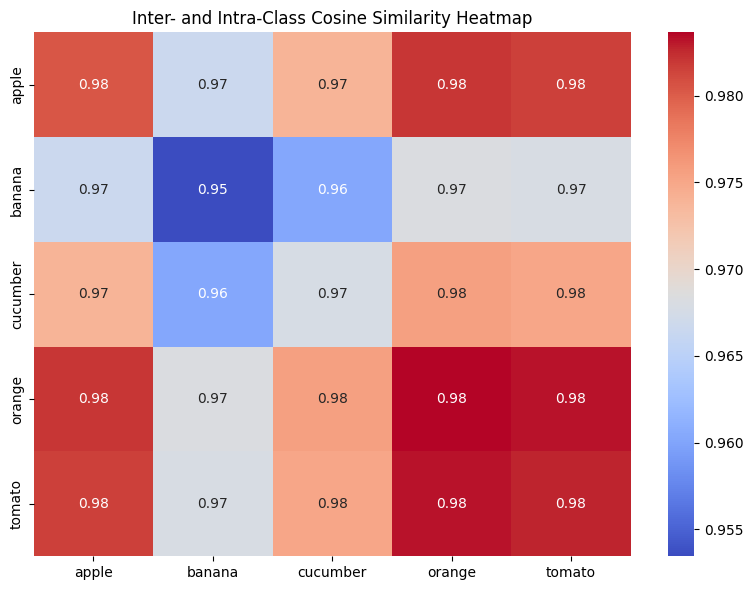

In [25]:
for c1 in classes:
    for c2 in classes:
        X1 = X[y == c1]
        X2 = X[y == c2]
        sims = cosine_similarity(X1, X2)
        similarity_matrix.loc[c1, c2] = sims.mean()

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Inter- and Intra-Class Cosine Similarity Heatmap")
plt.tight_layout()
plt.show()

- Inter class similarities are extremely high which results in non-discriminative features. We need to reconsider feature extraction methods.